# ✈️ U.S. Flight Delay Prediction (2001–2004)

This project predicts whether a flight will be delayed using U.S. domestic flight data (2001–2004) processed via Apache Hive on AWS EMR. Each team member exported one year's data from Hive; this notebook handles the combined 4-year dataset.

**Tools:** Python, pandas, scikit-learn, XGBoost, Hive (AWS EMR)

In [1]:
import warnings
warnings.filterwarnings("ignore")

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score

## 2. Load Data

Each team member exported their assigned year from Hive as a CSV sample (30,000 rows each). The files are merged into a single 120,000-row DataFrame.

> Note: `jinhwi_sample.csv` is the 2004 data queried and exported by this notebook's author.

In [3]:
columns = [
    "Year", "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime",
    "ArrTime", "CRSArrTime", "UniqueCarrier", "FlightNum", "TailNum",
    "ActualElapsedTime", "CRSElapsedTime", "AirTime", "ArrDelay", "DepDelay",
    "Origin", "Dest", "Distance", "TaxiIn", "TaxiOut", "Cancelled",
    "CancellationCode", "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay",
    "SecurityDelay", "LateAircraftDelay", "delay"
]

In [4]:
df1 = pd.read_csv('2004.csv',header=None, names=columns)
df2 = pd.read_csv('2008.csv',header=None, names=columns)
df3 = pd.read_csv('2001.csv',header=None, names=columns)
df4 = pd.read_csv('2003.csv',header=None, names=columns)

df1 = pd.DataFrame(df1)
df2 = pd.DataFrame(df2)
df3 = pd.DataFrame(df3)
df4 = pd.DataFrame(df4)

In [5]:
target = pd.read_excel('Target Data Set.xlsx', header=1)
target = pd.DataFrame(target)

In [6]:
df1.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,delay
0,2004,12,5,7,1001.0,1005,1225.0,1237,UA,146,...,7,0,NaN,0,0.0,0.0,0.0,0.0,0.0,N
1,2004,5,4,2,1108.0,1110,1254.0,1304,OO,6241,...,17,0,NaN,0,0.0,0.0,0.0,0.0,0.0,N
2,2004,6,17,4,1020.0,1020,1041.0,1051,EV,4208,...,21,0,NaN,0,0.0,0.0,0.0,0.0,0.0,N
3,2004,1,17,6,1201.0,1200,1256.0,1252,MQ,3113,...,18,0,NaN,0,0.0,0.0,0.0,0.0,0.0,Y
4,2004,4,7,3,1220.0,1220,1318.0,1310,WN,945,...,15,0,NaN,0,0.0,0.0,0.0,0.0,0.0,Y


## 3. Merge & Explore Data

In [7]:
merged_df = pd.concat([df1, df2,df3,df4], ignore_index = True)

In [8]:
print(merged_df.head())
print(merged_df.shape)
print(merged_df.info())

   Year  Month  DayofMonth  DayOfWeek DepTime  CRSDepTime ArrTime  CRSArrTime  \
0  2004     12           5          7  1001.0        1005  1225.0        1237   
1  2004      5           4          2  1108.0        1110  1254.0        1304   
2  2004      6          17          4  1020.0        1020  1041.0        1051   
3  2004      1          17          6  1201.0        1200  1256.0        1252   
4  2004      4           7          3  1220.0        1220  1318.0        1310   

  UniqueCarrier  FlightNum  ... TaxiOut Cancelled  CancellationCode Diverted  \
0            UA        146  ...     7.0         0               NaN        0   
1            OO       6241  ...    17.0         0               NaN        0   
2            EV       4208  ...    21.0         0               NaN        0   
3            MQ       3113  ...    18.0         0               NaN        0   
4            WN        945  ...    15.0         0               NaN        0   

  CarrierDelay WeatherDelay NASD

## 4. Preprocessing

- Replace `\\N` (Hive null) with NaN
- Drop `CancellationCode` (97% missing)
- Numeric conversion
- One-hot encoding for carrier, origin, destination
- Missing value imputation (mean or 0 based on zero-ratio threshold)

In [9]:
merged_df.replace('\\N', np.nan, inplace = True)
merged_df.drop(columns='CancellationCode', inplace = True)

In [10]:
target_df = merged_df['delay']
merged_df.drop(columns='delay', inplace=True)

In [11]:
numeric_cols = ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
                'ArrTime', 'CRSArrTime', 'FlightNum', 'ActualElapsedTime', 'CRSElapsedTime',
                'AirTime', 'ArrDelay', 'DepDelay', 'Distance', 'TaxiIn', 'TaxiOut',
                'Cancelled', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
                'SecurityDelay', 'LateAircraftDelay']


for col in numeric_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')


merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [12]:
original_df = merged_df.copy()

In [13]:
merged_df = pd.get_dummies(merged_df, columns=['UniqueCarrier', 'Origin', 'Dest'])

In [14]:
for col in merged_df:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

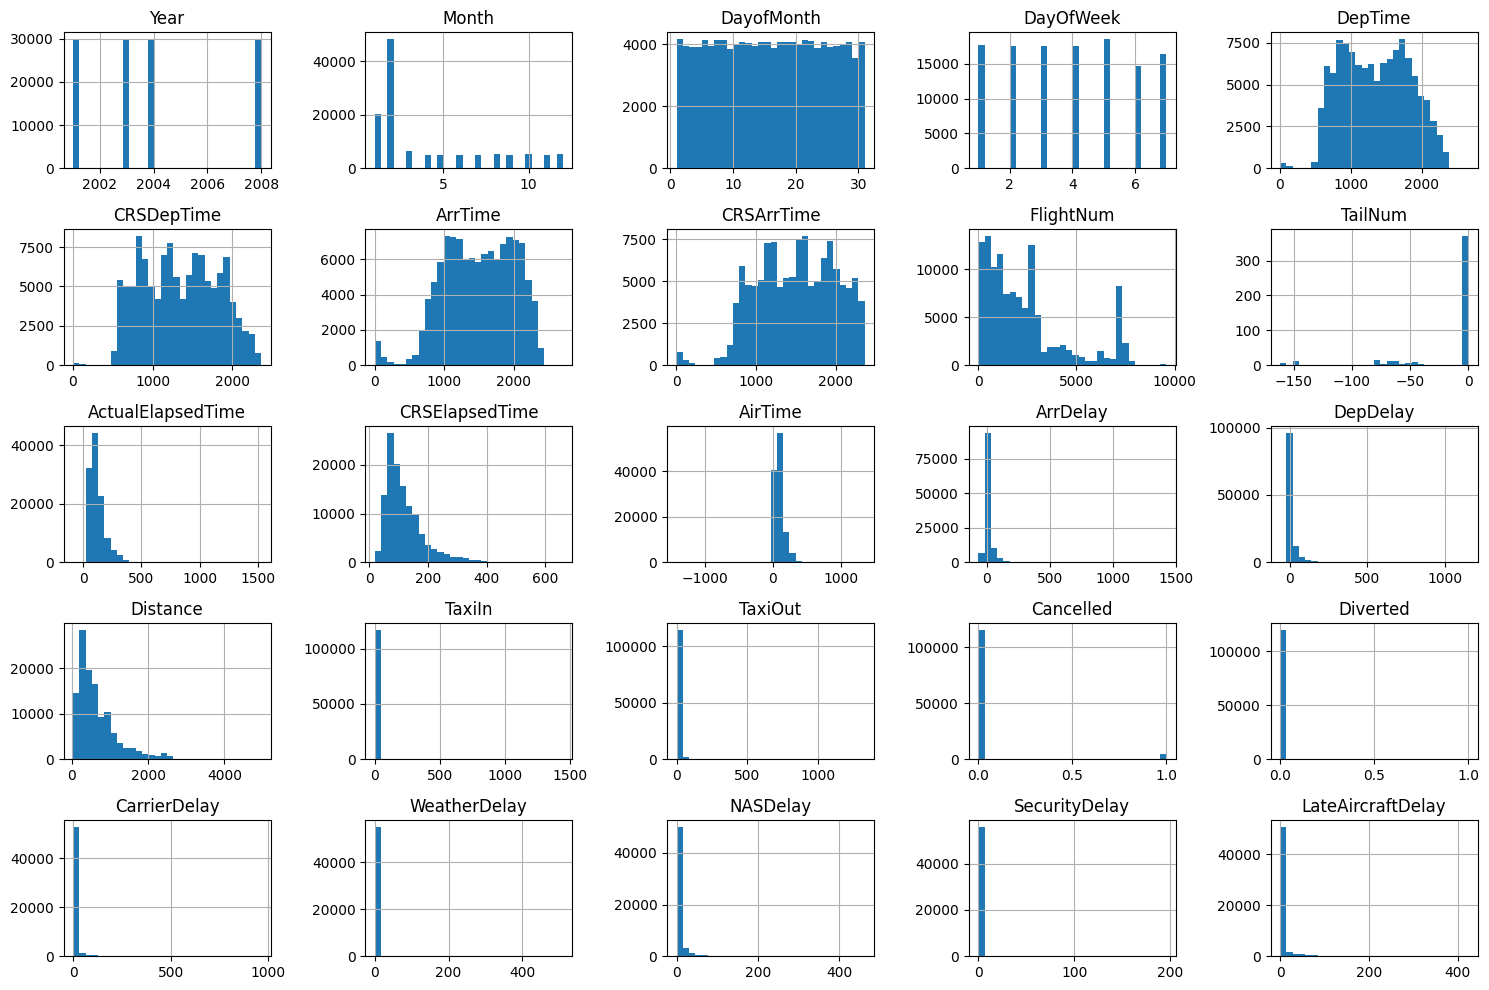

In [15]:
merged_df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [16]:
merged_df.drop(columns = ['Year','Month','DayofMonth','DayOfWeek','TaxiIn','TaxiOut','Cancelled','Diverted'], inplace = True)

In [17]:
merged_df.isna().sum()

DepTime       4390
CRSDepTime       0
ArrTime       4611
CRSArrTime       0
FlightNum        0
              ... 
Dest_WRG         0
Dest_WYS         0
Dest_XNA         0
Dest_YAK         0
Dest_YUM         0
Length: 612, dtype: int64

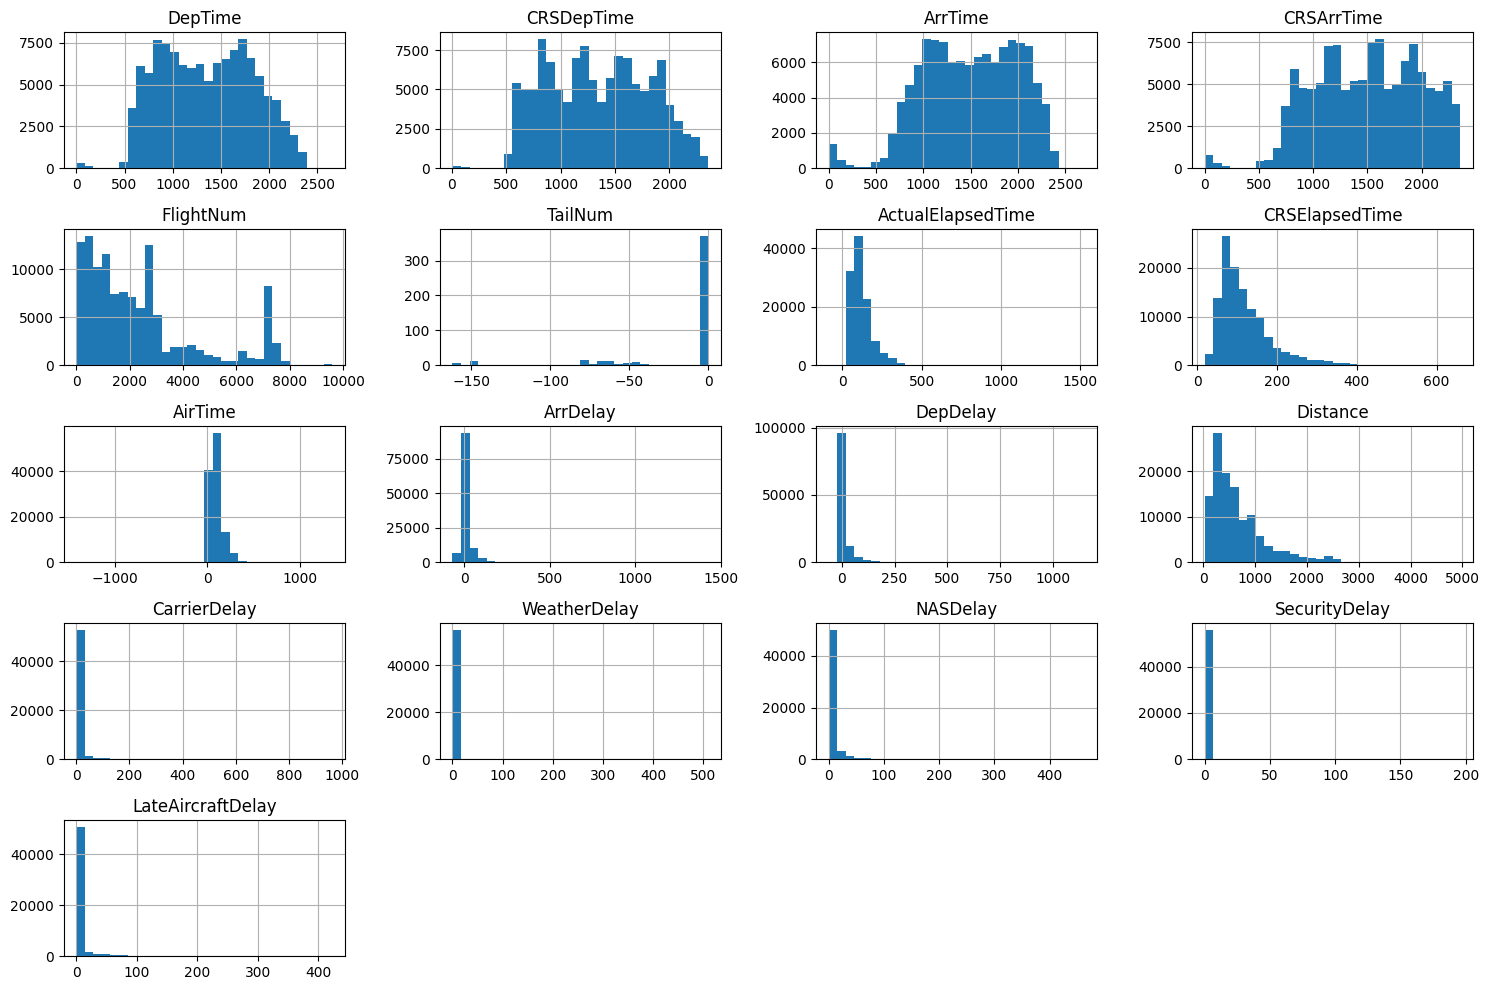

In [18]:
merged_df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [19]:
onehot_prefixes = ['Origin_', 'Dest_', 'UniqueCarrier_']  

for col in merged_df.columns:
 
    if any(col.startswith(prefix) for prefix in onehot_prefixes):
        continue

    zero_ratio = merged_df[col][merged_df[col].notna()].eq(0).mean()

    if zero_ratio > 0.9:
        merged_df[col].fillna(0, inplace=True)
        print(f"{col}: Filled with 0 (Zero ratio: {zero_ratio:.2%})")
    else:
        if pd.to_numeric(merged_df[col], errors='coerce').notna().any():
            mean_value = pd.to_numeric(merged_df[col], errors='coerce').mean()
            merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
            merged_df[col].fillna(mean_value, inplace=True)
            print(f"{col}: Filled with mean ({mean_value:.2f}) (Zero ratio: {zero_ratio:.2%})")

DepTime: Filled with mean (1352.86) (Zero ratio: 0.00%)
CRSDepTime: Filled with mean (1345.20) (Zero ratio: 0.00%)
ArrTime: Filled with mean (1493.22) (Zero ratio: 0.00%)
CRSArrTime: Filled with mean (1498.85) (Zero ratio: 0.00%)
FlightNum: Filled with mean (2362.81) (Zero ratio: 0.00%)
TailNum: Filled with mean (-16.46) (Zero ratio: 79.96%)
ActualElapsedTime: Filled with mean (118.06) (Zero ratio: 0.00%)
CRSElapsedTime: Filled with mean (118.56) (Zero ratio: 0.00%)
AirTime: Filled with mean (96.42) (Zero ratio: 0.00%)
ArrDelay: Filled with mean (8.70) (Zero ratio: 4.27%)
DepDelay: Filled with mean (9.76) (Zero ratio: 18.44%)
Distance: Filled with mean (650.98) (Zero ratio: 0.00%)
CarrierDelay: Filled with mean (6.02) (Zero ratio: 87.16%)
WeatherDelay: Filled with 0 (Zero ratio: 97.96%)
NASDelay: Filled with mean (5.58) (Zero ratio: 83.74%)
SecurityDelay: Filled with 0 (Zero ratio: 99.81%)
LateAircraftDelay: Filled with mean (5.87) (Zero ratio: 88.95%)


In [20]:
merged_df.isna().sum()

DepTime       0
CRSDepTime    0
ArrTime       0
CRSArrTime    0
FlightNum     0
             ..
Dest_WRG      0
Dest_WYS      0
Dest_XNA      0
Dest_YAK      0
Dest_YUM      0
Length: 612, dtype: int64

In [21]:
for col in merged_df:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

## 5. Modeling

### 5-1. Logistic Regression (One-hot encoded features)

In [22]:
X = merged_df
y = target_df

if y.dtype == 'object':
    y = y.map({'Y': 1, 'N': 0})

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 2025)

In [23]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test,y_pred))
print('Precision:', precision_score(y_test,y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test,y_pred))
print('\nClassification Report:\n', classification_report(y_test,y_pred))

Accuracy: 0.933
Precision: 0.9421310956301456

Confusion Matrix:
 [[10491   731]
 [  877 11901]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93     11222
           1       0.94      0.93      0.94     12778

    accuracy                           0.93     24000
   macro avg       0.93      0.93      0.93     24000
weighted avg       0.93      0.93      0.93     24000



In [25]:
cols = [
    'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'FlightNum', 'TailNum',
    'ActualElapsedTime', 'CRSElapsedTime', 'ArrDelay', 'DepDelay',
    'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
    'SecurityDelay', 'LateAircraftDelay'
]

target_new = target[cols]

In [26]:
original_target = target.copy()

In [27]:
target = pd.get_dummies(target)

In [28]:
X.columns

Index(['DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'FlightNum',
       'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       ...
       'Dest_TYS', 'Dest_VCT', 'Dest_VIS', 'Dest_VLD', 'Dest_VPS', 'Dest_WRG',
       'Dest_WYS', 'Dest_XNA', 'Dest_YAK', 'Dest_YUM'],
      dtype='object', length=612)

In [29]:
target

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,FlightNum,ActualElapsedTime,...,TailNum_N807MD,TailNum_N813MA,TailNum_N826MD,Origin_DCA,Origin_JNU,Origin_PIT,Dest_DFW,Dest_KTN,Dest_PHL,Delayed_?
0,NaN,NaN,14,2,2005,2000,NaN,2057,1907,57,...,False,False,False,False,False,True,False,False,True,True
1,NaN,NaN,14,2,845,825,NaN,1055,1685,189,...,False,False,False,True,False,False,True,False,False,True
2,NaN,NaN,16,2,708,710,NaN,800,60,55,...,False,False,False,False,True,False,False,True,False,True
3,NaN,NaN,21,2,2123,2100,NaN,2159,1880,73,...,False,False,False,False,False,True,False,False,True,True
4,NaN,NaN,21,2,840,825,NaN,1055,1685,237,...,False,False,True,True,False,False,True,False,False,True
5,NaN,NaN,23,2,710,710,NaN,800,60,47,...,False,False,False,False,True,False,False,True,False,True
6,NaN,NaN,28,2,2113,2100,NaN,2159,1880,59,...,False,False,False,False,False,True,False,False,True,True
7,NaN,NaN,28,2,825,825,NaN,1055,1685,188,...,True,False,False,True,False,False,True,False,False,True
8,NaN,NaN,1,3,1958,2000,NaN,2057,1907,59,...,False,False,False,False,False,True,False,False,True,True
9,NaN,NaN,1,3,823,825,NaN,1055,1685,220,...,False,True,False,True,False,False,True,False,False,True


In [30]:
expected_columns = X.columns

missing_cols = set(expected_columns) - set(target.columns)

for col in missing_cols:
    target[col] = 0

target = target[expected_columns]

In [31]:
print(X.shape)
print(target.shape)

(120000, 612)
(10, 612)


In [32]:
target['ArrTime'] = 0

In [33]:
target.head()

,DepTime,CRSDepTime,ArrTime,CRSArrTime,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,...,Dest_TYS,Dest_VCT,Dest_VIS,Dest_VLD,Dest_VPS,Dest_WRG,Dest_WYS,Dest_XNA,Dest_YAK,Dest_YUM
0,2005,2000,0,2057,1907,0,57,57,0,NaN,...,0,0,0,0,0,0,0,0,0,0
1,845,825,0,1055,1685,0,189,210,0,NaN,...,0,0,0,0,0,0,0,0,0,0
2,708,710,0,800,60,0,55,50,0,NaN,...,0,0,0,0,0,0,0,0,0,0
3,2123,2100,0,2159,1880,0,73,59,0,NaN,...,0,0,0,0,0,0,0,0,0,0
4,840,825,0,1055,1685,0,237,210,0,NaN,...,0,0,0,0,0,0,0,0,0,0


In [34]:
target = target.fillna(0)

In [35]:
target_pred = model.predict(target)

In [36]:
target

,DepTime,CRSDepTime,ArrTime,CRSArrTime,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,...,Dest_TYS,Dest_VCT,Dest_VIS,Dest_VLD,Dest_VPS,Dest_WRG,Dest_WYS,Dest_XNA,Dest_YAK,Dest_YUM
0,2005,2000,0,2057,1907,0,57,57,0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,845,825,0,1055,1685,0,189,210,0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,708,710,0,800,60,0,55,50,0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,2123,2100,0,2159,1880,0,73,59,0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,840,825,0,1055,1685,0,237,210,0,0.0,...,0,0,0,0,0,0,0,0,0,0
5,710,710,0,800,60,0,47,50,0,0.0,...,0,0,0,0,0,0,0,0,0,0
6,2113,2100,0,2159,1880,0,59,59,0,0.0,...,0,0,0,0,0,0,0,0,0,0
7,825,825,0,1055,1685,0,188,210,0,0.0,...,0,0,0,0,0,0,0,0,0,0
8,1958,2000,0,2057,1907,0,59,57,0,0.0,...,0,0,0,0,0,0,0,0,0,0
9,823,825,0,1055,1685,0,220,210,0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
target_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [38]:
target['delay'] = 'Y'

In [39]:
target

,DepTime,CRSDepTime,ArrTime,CRSArrTime,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,...,Dest_VCT,Dest_VIS,Dest_VLD,Dest_VPS,Dest_WRG,Dest_WYS,Dest_XNA,Dest_YAK,Dest_YUM,delay
0,2005,2000,0,2057,1907,0,57,57,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
1,845,825,0,1055,1685,0,189,210,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
2,708,710,0,800,60,0,55,50,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
3,2123,2100,0,2159,1880,0,73,59,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
4,840,825,0,1055,1685,0,237,210,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
5,710,710,0,800,60,0,47,50,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
6,2113,2100,0,2159,1880,0,59,59,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
7,825,825,0,1055,1685,0,188,210,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
8,1958,2000,0,2057,1907,0,59,57,0,0.0,...,0,0,0,0,0,0,0,0,0,Y
9,823,825,0,1055,1685,0,220,210,0,0.0,...,0,0,0,0,0,0,0,0,0,Y


### 5-2. Logistic Regression (Numeric features only)

In [40]:
original_df

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2004,12,5,7,1001.0,1005,1225.0,1237,UA,146,...,533,2.0,7.0,0,0,0.0,0.0,0.0,0.0,0.0
1,2004,5,4,2,1108.0,1110,1254.0,1304,OO,6241,...,462,2.0,17.0,0,0,0.0,0.0,0.0,0.0,0.0
2,2004,6,17,4,1020.0,1020,1041.0,1051,EV,4208,...,247,2.0,21.0,0,0,0.0,0.0,0.0,0.0,0.0
3,2004,1,17,6,1201.0,1200,1256.0,1252,MQ,3113,...,109,6.0,18.0,0,0,0.0,0.0,0.0,0.0,0.0
4,2004,4,7,3,1220.0,1220,1318.0,1310,WN,945,...,174,3.0,15.0,0,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,2003,2,3,1,630.0,630,724.0,735,WN,2882,...,236,3.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN
119996,2003,7,30,3,734.0,728,828.0,833,MQ,4010,...,273,3.0,8.0,0,0,0.0,0.0,0.0,0.0,0.0
119997,2003,12,17,3,1732.0,1640,1827.0,1738,OO,3679,...,223,4.0,9.0,0,0,49.0,0.0,0.0,0.0,0.0
119998,2003,11,2,7,2105.0,2115,2210.0,2233,DH,7247,...,326,4.0,8.0,0,0,0.0,0.0,0.0,0.0,0.0


In [41]:
original_df.drop(columns = ['Year','Month','DayofMonth','DayOfWeek','TaxiIn','TaxiOut','Cancelled','Diverted', 'AirTime'], inplace = True)

for col in original_df.columns:     

    zero_ratio = original_df[col][original_df[col].notna()].eq(0).mean()

    if zero_ratio > 0.9:
        original_df[col].fillna(0, inplace=True)
        print(f"{col}: Filled with 0 (Zero ratio: {zero_ratio:.2%})")
    else:
        if pd.to_numeric(original_df[col], errors='coerce').notna().any():
            mean_value = pd.to_numeric(original_df[col], errors='coerce').mean()
            original_df[col] = pd.to_numeric(original_df[col], errors='coerce')
            original_df[col].fillna(mean_value, inplace=True)
            print(f"{col}: Filled with mean ({mean_value:.2f}) (Zero ratio: {zero_ratio:.2%})")

DepTime: Filled with mean (1352.86) (Zero ratio: 0.00%)
CRSDepTime: Filled with mean (1345.20) (Zero ratio: 0.00%)
ArrTime: Filled with mean (1493.22) (Zero ratio: 0.00%)
CRSArrTime: Filled with mean (1498.85) (Zero ratio: 0.00%)
FlightNum: Filled with mean (2362.81) (Zero ratio: 0.00%)
TailNum: Filled with mean (-16.46) (Zero ratio: 0.00%)
ActualElapsedTime: Filled with mean (118.06) (Zero ratio: 0.00%)
CRSElapsedTime: Filled with mean (118.56) (Zero ratio: 0.00%)
ArrDelay: Filled with mean (8.70) (Zero ratio: 4.27%)
DepDelay: Filled with mean (9.76) (Zero ratio: 18.44%)
Distance: Filled with mean (650.98) (Zero ratio: 0.00%)
CarrierDelay: Filled with mean (6.02) (Zero ratio: 87.16%)
WeatherDelay: Filled with 0 (Zero ratio: 97.96%)
NASDelay: Filled with mean (5.58) (Zero ratio: 83.74%)
SecurityDelay: Filled with 0 (Zero ratio: 99.81%)
LateAircraftDelay: Filled with mean (5.87) (Zero ratio: 88.95%)


In [42]:
original_df.drop(columns = ['UniqueCarrier','Origin','Dest', 'ArrTime','ArrDelay', 'DepDelay'], inplace = True)
original_df.isna().sum()

DepTime              0
CRSDepTime           0
CRSArrTime           0
FlightNum            0
TailNum              0
ActualElapsedTime    0
CRSElapsedTime       0
Distance             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
dtype: int64

In [43]:
original_df.drop(columns = 'TailNum', inplace= True)
X2 = original_df
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size = 0.2, random_state = 2025)

In [44]:
model2 = LogisticRegression(max_iter = 1000)
model2.fit(X2_train, y2_train)

LogisticRegression(max_iter=1000)

In [45]:
y2_pred = model2.predict(X2_test)

print('Accuracy:', accuracy_score(y2_test,y2_pred))
print('Precision:', precision_score(y2_test,y2_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y2_test,y2_pred))
print('\nClassification Report:\n', classification_report(y2_test,y2_pred))

Accuracy: 0.7180833333333333
Precision: 0.7467575110819241

Confusion Matrix:
 [[8137 3085]
 [3681 9097]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.73      0.71     11222
           1       0.75      0.71      0.73     12778

    accuracy                           0.72     24000
   macro avg       0.72      0.72      0.72     24000
weighted avg       0.72      0.72      0.72     24000



In [46]:
X2.columns

Index(['DepTime', 'CRSDepTime', 'CRSArrTime', 'FlightNum', 'ActualElapsedTime',
       'CRSElapsedTime', 'Distance', 'CarrierDelay', 'WeatherDelay',
       'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')

In [47]:
original_target = original_target[['DepTime', 'CRSDepTime', 'CRSArrTime', 'FlightNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'Distance', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']]

In [48]:
original_target

,DepTime,CRSDepTime,CRSArrTime,FlightNum,ActualElapsedTime,CRSElapsedTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2005,2000,2057,1907,57,57,267,NaN,NaN,NaN,NaN,NaN
1,845,825,1055,1685,189,210,1192,0.0,0.0,0.0,0.0,0.0
2,708,710,800,60,55,50,0,NaN,NaN,NaN,NaN,NaN
3,2123,2100,2159,1880,73,59,267,NaN,NaN,NaN,NaN,NaN
4,840,825,1055,1685,237,210,1192,15.0,0.0,27.0,0.0,0.0
5,710,710,800,60,47,50,0,NaN,NaN,NaN,NaN,NaN
6,2113,2100,2159,1880,59,59,267,NaN,NaN,NaN,NaN,NaN
7,825,825,1055,1685,188,210,1192,0.0,0.0,0.0,0.0,0.0
8,1958,2000,2057,1907,59,57,267,NaN,NaN,NaN,NaN,NaN
9,823,825,1055,1685,220,210,1192,0.0,0.0,0.0,0.0,0.0


In [49]:
for col in original_df.columns:     

    zero_ratio = original_target[col][original_target[col].notna()].eq(0).mean()

    if zero_ratio > 0.9:
        original_target[col].fillna(0, inplace=True)
        print(f"{col}: Filled with 0 (Zero ratio: {zero_ratio:.2%})")
    else:
        if pd.to_numeric(original_target[col], errors='coerce').notna().any():
            mean_value = pd.to_numeric(original_target[col], errors='coerce').mean()
            original_target[col] = pd.to_numeric(original_target[col], errors='coerce')
            original_target[col].fillna(mean_value, inplace=True)
            print(f"{col}: Filled with mean ({mean_value:.2f}) (Zero ratio: {zero_ratio:.2%})")

DepTime: Filled with mean (1295.00) (Zero ratio: 0.00%)
CRSDepTime: Filled with mean (1292.00) (Zero ratio: 0.00%)
CRSArrTime: Filled with mean (1425.20) (Zero ratio: 0.00%)
FlightNum: Filled with mean (1443.40) (Zero ratio: 0.00%)
ActualElapsedTime: Filled with mean (118.40) (Zero ratio: 0.00%)
CRSElapsedTime: Filled with mean (117.20) (Zero ratio: 0.00%)
Distance: Filled with mean (583.60) (Zero ratio: 20.00%)
CarrierDelay: Filled with mean (3.75) (Zero ratio: 75.00%)
WeatherDelay: Filled with 0 (Zero ratio: 100.00%)
NASDelay: Filled with mean (6.75) (Zero ratio: 75.00%)
SecurityDelay: Filled with 0 (Zero ratio: 100.00%)
LateAircraftDelay: Filled with 0 (Zero ratio: 100.00%)


In [50]:
original_target.isna().sum()

DepTime              0
CRSDepTime           0
CRSArrTime           0
FlightNum            0
ActualElapsedTime    0
CRSElapsedTime       0
Distance             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
dtype: int64

In [51]:
original_target_pred = model2.predict(original_target)

In [52]:
original_target_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1])

### 5-3. Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
R_model = RandomForestClassifier()
R_model.fit(X2_train, y2_train)

RandomForestClassifier()

In [55]:
R_pred = R_model.predict(X2_test)

print('Accuracy:', accuracy_score(y2_test,R_pred))
print('Precision:', precision_score(y2_test,R_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y2_test,R_pred))
print('\nClassification Report:\n', classification_report(y2_test,R_pred))

Accuracy: 0.8169583333333333
Precision: 0.867215555750197

Confusion Matrix:
 [[9706 1516]
 [2877 9901]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.86      0.82     11222
           1       0.87      0.77      0.82     12778

    accuracy                           0.82     24000
   macro avg       0.82      0.82      0.82     24000
weighted avg       0.82      0.82      0.82     24000



### 5-4. XGBoost

In [56]:
from xgboost import XGBClassifier

In [57]:
XG_model = XGBClassifier(random_state=2025)
XG_model.fit(X2_train, y2_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [58]:
XG_pred = XG_model.predict(X2_test)

print('Accuracy:', accuracy_score(y2_test,XG_pred))
print('Precision:', precision_score(y2_test,XG_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y2_test,XG_pred))
print('\nClassification Report:\n', classification_report(y2_test,XG_pred))

Accuracy: 0.9022083333333333
Precision: 0.950116509881764

Confusion Matrix:
 [[10644   578]
 [ 1769 11009]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     11222
           1       0.95      0.86      0.90     12778

    accuracy                           0.90     24000
   macro avg       0.90      0.91      0.90     24000
weighted avg       0.91      0.90      0.90     24000



In [59]:
XG_target_pred = XG_model.predict(original_target)

## 6. Final Prediction on Target Dataset

XGBoost achieved the best performance (Accuracy: 90.2%, Precision: 95.0%) and was used for final predictions on the unlabeled target dataset.

In [60]:
XG_target_pred

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 1])

## 7. Model Performance Summary

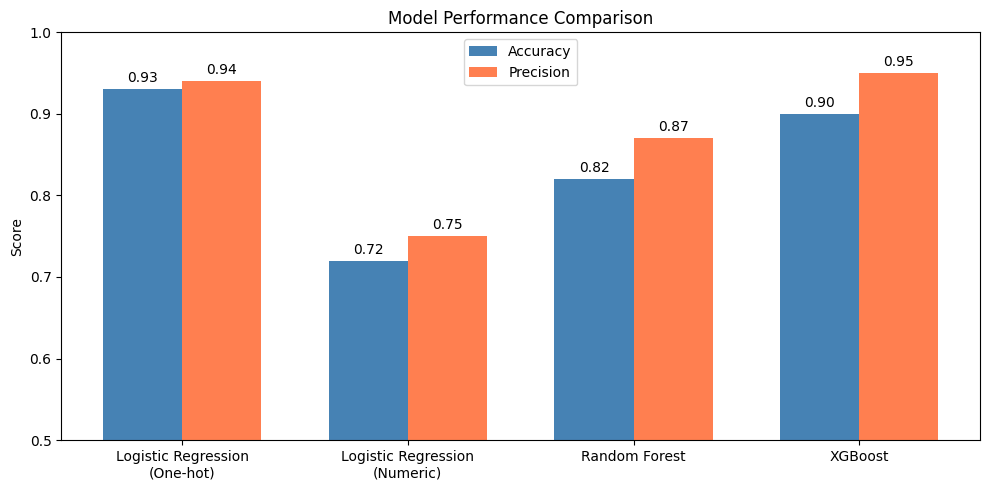

In [61]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression\n(One-hot)', 'Logistic Regression\n(Numeric)', 'Random Forest', 'XGBoost']
accuracies = [0.93, 0.72, 0.82, 0.90]
precisions = [0.94, 0.75, 0.87, 0.95]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, precisions, width, label='Precision', color='coral')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)
plt.tight_layout()
plt.show()


## 8. XGBoost Feature Importance

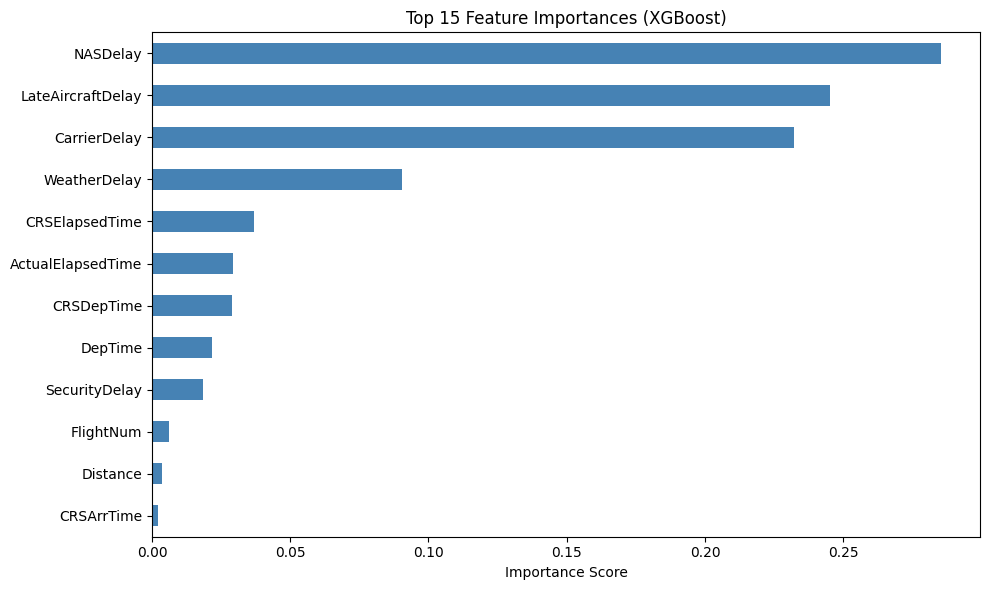

In [62]:
feat_imp = pd.Series(XG_model.feature_importances_, index=X2.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Importances (XGBoost)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()